In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
# from shop.plotting.plotting_fxns import *
from get_ddf import get_ddf_df
from data_handling import SnowMelt
import statsmodels.api as sm
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

In [34]:
data = SnowMelt('gulkana','B')
ds = xr.open_dataset(base_fp + 'gulkanaB_2026_02_03_base_long_0.nc')
data.get_model_snow(ds)
data.model_error_metric(data.mod_melt, data.sar_melt, data.time, transition_type='onset')

TypeError: SnowMelt.model_error_metric() got an unexpected keyword argument 'transition_type'

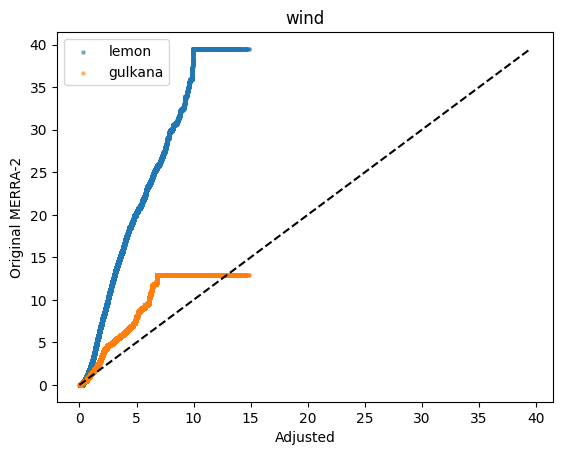

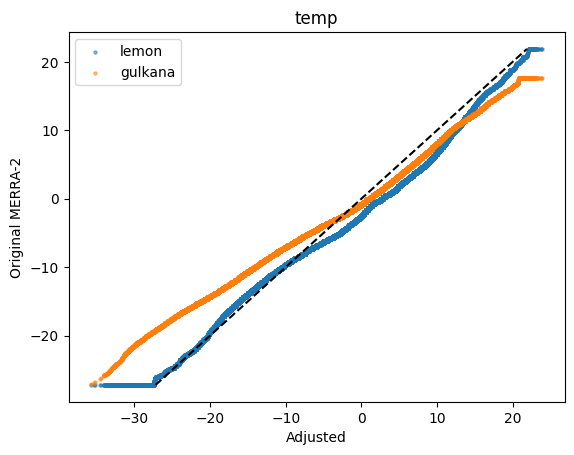

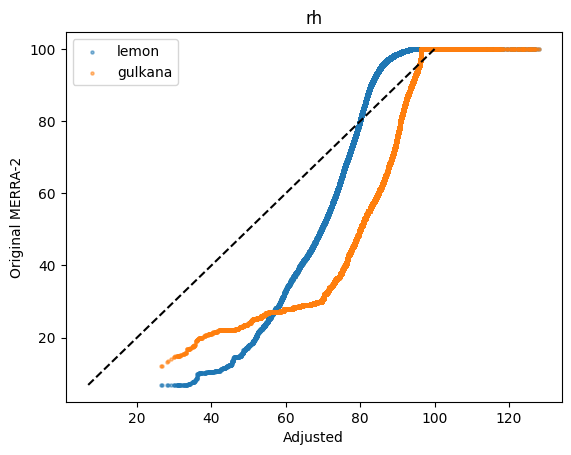

In [20]:
#comparing quantile mapping approaches
# ds_lemon = xr.open_dataset(base_fp + 'takuTKG3_2026_02_15_base_qmlemonkp2_0.nc')
# ds_gulk = xr.open_dataset(base_fp + 'takuTKG3_2026_02_12_base_qmallkp2_0.nc')

coords = '58.5_-134.3'
for var in ['wind','temp','rh']:
    if var == 'wind':
        dsu = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/U2M_{coords}.nc')['U2M']
        dsv = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/V2M_{coords}.nc')['V2M']
        ds_clim = np.sqrt(np.square(dsu.values) + np.square(dsv.values))
    elif var == 'rh':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/RH2M_{coords}.nc')['RH2M'].values
    elif var == 'temp':
        ds_clim = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/T2M_{coords}.nc')['T2M'].values - 273.15
    varn = var if var != 'temp' else 'temp_0'
    df_gulk = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_gulkana_{varn}.csv')
    df_lem = pd.read_csv(f'../data/bias_adjustment/quantile_mapping_lemon_creek_{varn}.csv')
        
    # interpolate values according to quantile mapping
    values = ds_clim
    adj_gulk = np.interp(values, df_gulk['sorted'], df_gulk['mapping'])
    adj_lem = np.interp(values, df_lem['sorted'], df_lem['mapping'])

    # plt.scatter(adj_gulk, adj_lem, s=5, alpha=0.5)
    plt.scatter(values, adj_lem, s=5, alpha=0.5,label='lemon')
    plt.scatter(values, adj_gulk, s=5, alpha=0.5,label='gulkana')
    minn = np.min([adj_gulk, adj_lem])
    maxx = np.max([adj_gulk, adj_lem])
    plt.ylabel('Original MERRA-2') # Lemon Creek adjusted')
    plt.xlabel('Adjusted') # Gulkana adjusted')
    plt.plot([minn,maxx],[minn,maxx],'k--')
    plt.legend()
    plt.title(var)
    plt.show()

/trace/home/cvwilson/miniconda3/envs/eb_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


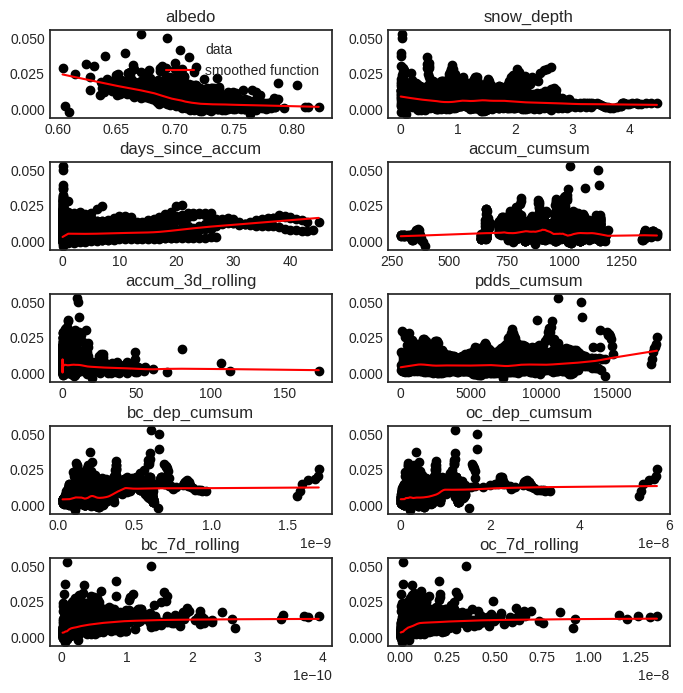

In [ ]:
target = 'ddf'
df = pd.read_csv(base_fp + 'gulkanaB_ddf.csv')
fig, axes = plt.subplots(len(df.columns[1:]) // 2, 2, figsize=(8, 8),
                       gridspec_kw = {'hspace':0.5})
axes = axes.flatten()
for c, col in enumerate(df.columns[1:]):
    data = df[col]
    smoothed = sm.nonparametric.lowess(endog=df[target], exog=df[col], frac=0.2)

    axes[c].scatter(data, df[target], label='data', color='k')
    axes[c].plot(smoothed[:, 0], smoothed[:, 1], c='r', label='smoothed function')
    axes[c].set_title(col)
axes[0].legend()
plt.show()

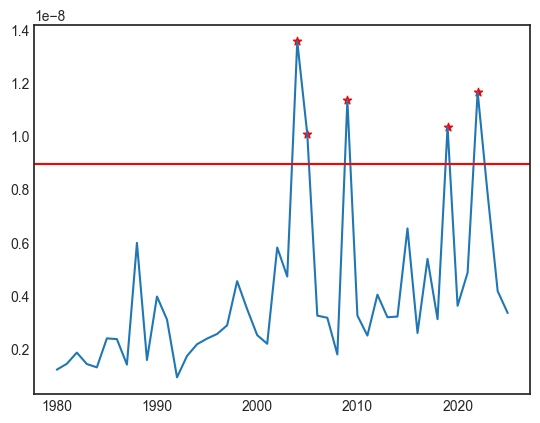

In [51]:
ds = xr.open_dataset('../climate_data/MERRA2/BCDP002/MERRA2_BCDP002_gulkana_alltime.nc')
ds2 = xr.open_dataset('../climate_data/MERRA2/BCWT002/MERRA2_BCWT002_gulkana_alltime.nc')
ds['BCDP002'] = ds['BCDP002'] + ds2['BCWT002']
# define time variables
months = ds['time'].dt.month
days = ds['time'].dt.day
# create time mask from apr 1 to sep 30 (inclusive)
mask = ((months > 3) & (months < 10))
ds_season = ds.where(mask, drop=True)
annual_sums = ds_season.groupby('time.year').sum()
plt.plot(annual_sums.year, annual_sums['BCDP002'].values)
plt.axhline(np.quantile(annual_sums['BCDP002'].values, 0.90), c='r')

threshold = np.quantile(annual_sums['BCDP002'].values, 0.90)
base_idx = np.where(annual_sums['BCDP002'].values <= threshold)[0]
fire_idx = np.where(annual_sums['BCDP002'].values > threshold)[0]
plt.scatter(annual_sums.year.values[fire_idx], annual_sums['BCDP002'].values[fire_idx], color='red', marker='*')
plt.show()

fire_years = annual_sums.year.values[fire_idx]
base_years = annual_sums.year.values[base_idx]

AU snow difference in Normal years     mean: 0.216     median: 0.181
AU snow difference in Fire years     mean: 0.190     median: 0.160
B snow difference in Normal years     mean: 0.199     median: 0.160
B snow difference in Fire years     mean: 0.244     median: 0.231
D snow difference in Normal years     mean: 0.198     median: 0.141
D snow difference in Fire years     mean: 0.304     median: 0.257


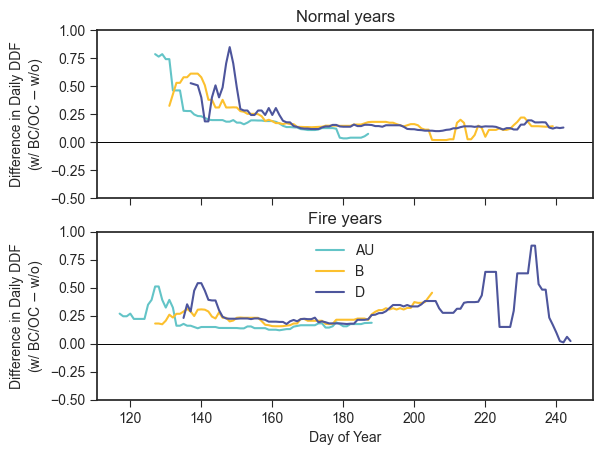

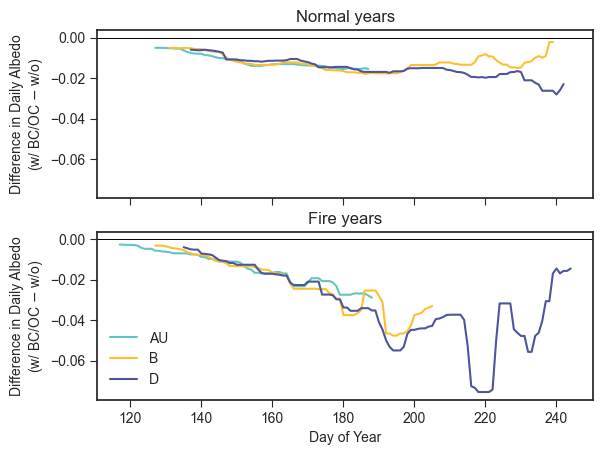

In [89]:
for plot_type in ['difference', ]: # 'values',
    fig_ddf, axes_ddf = plt.subplots(2, sharex=True, sharey=True)
    fig_albedo, axes_albedo = plt.subplots(2, sharex=True, sharey=True)
    for s, site in enumerate(['AU','B','D']): # ,'B','D','Z'
        cc = colors[s]
        ds_base = xr.open_dataset(base_fp + f'gulkana{site}_2026_02_03_base_long_0.nc')
        ds_noBCOC = xr.open_dataset(base_fp + f'gulkana{site}_2026_02_03_noBCOC_long_0.nc')
        # ds_noBCOC = ds_base
        ds_dict = {'wBCOC':ds_base, 'base':ds_noBCOC}
        linestyles = ['-','--']
        
        for axd, axa, years, label in zip(axes_ddf, axes_albedo,
                                    [base_years, fire_years],
                                    ['Normal years', 'Fire years']):

            # storage for plotting
            x_snow = []
            y_snow = []
            x_ice = []
            y_ice = []
            x_albedo = []
            y_albedo = []

            # compute per-dataset climatologies FIRST
            results = {}

            for dataset in ['base', 'wBCOC']:
                ds = ds_dict[dataset]

                ddfs_snow = []
                ddfs_ice = []
                albedo_list = []

                for year in years:
                    if year < 2000 or pd.to_datetime(f'{year}-05-01') not in ds.time:
                        continue

                    subset = ds.sel(time=slice(f"{year}-04-01", f"{year}-10-01"))

                    melt = subset['melt'].resample(time='1D').sum() * 1000
                    PDDs = subset['airtemp'].resample(time='1D').mean().clip(min=0)
                    albedo_daily = subset['albedo'].resample(time='1D').mean()

                    snowdepth = (
                        subset.where(subset['layertype'] < 2)['layerheight']
                        .sum(dim='layer')
                        .resample(time='1D')
                        .min()
                    )
                    layertype_min = (
                        subset['layertype'].isel(layer=0)
                        .resample(time='1D')
                        .min()
                        .astype(int)
                    )

                    # --- snow ---
                    cond_snow = (melt > 2) & (snowdepth > 0.05) & (PDDs > 0)
                    ddf_snow = (melt.where(cond_snow) / PDDs.where(cond_snow))
                    ddfs_snow.append(ddf_snow)

                    # --- ice ---
                    cond_ice = layertype_min > 1
                    ddf_ice = (melt.where(cond_ice) / PDDs)
                    ddfs_ice.append(ddf_ice)

                    albedo_list.append(albedo_daily.where(cond_snow))

                # concat across years
                all_snow = xr.concat(ddfs_snow, dim="time")
                all_ice = xr.concat(ddfs_ice, dim="time")
                all_albedo = xr.concat(albedo_list, dim="time")

                # group by DOY (no rolling yet)
                min_years = 5 if 'Normal' in label else 2
                snow_mask = (all_snow.groupby("time.dayofyear").count()) >= min_years
                snow_DOY = all_snow.groupby("time.dayofyear").mean().where(snow_mask)
                ice_mask = (all_ice.groupby("time.dayofyear").count()) >= min_years
                ice_DOY = all_ice.groupby("time.dayofyear").mean().where(ice_mask)
                albedo_mask = (all_albedo.groupby("time.dayofyear").count()) >= min_years
                albedo_DOY = all_albedo.groupby("time.dayofyear").mean().where(albedo_mask)

                results[dataset] = {
                    "snow": snow_DOY,
                    "ice": ice_DOY,
                    "albedo": albedo_DOY,
                    "snow_all": all_snow
                }

            # ---------------------------------------------------------
            # NOW compute differences (wBCOC − base), THEN rolling mean
            # ---------------------------------------------------------

            # print(site,results['wBCOC']['snow_all'].time.values[np.where(results['wBCOC']['snow'] - results['base']['snow'] < 0)[0]])
            snow_diff = (results['wBCOC']['snow'] - results['base']['snow']).rolling(dayofyear=7, center=True, min_periods=5).median()
            ice_diff = (results['wBCOC']['ice'] - results['base']['ice']).rolling(dayofyear=7, center=True, min_periods=5).median()
            albedo_diff = (results['wBCOC']['albedo'] - results['base']['albedo']).rolling(dayofyear=7, center=True, min_periods=5).median()

            # extract x/y for plotting
            x_snow = snow_diff['dayofyear'].values
            y_snow = snow_diff.values
            print(site,'snow difference in', label, f'    mean: {np.nanmean(y_snow):.3f}     median: {np.nanmedian(y_snow):.3f}')

            x_ice = ice_diff['dayofyear'].values
            y_ice = ice_diff.values

            x_albedo = albedo_diff['dayofyear'].values
            y_albedo = albedo_diff.values

            # ---------------------------------------------------------
            # Plot
            # ---------------------------------------------------------

            if plot_type == 'difference':
                axd.plot(x_snow, y_snow, color=cc, linestyle='-',label=site)
                # axd.plot(x_ice, y_ice, color=cc, linestyle='--')
                axd.axhline(0, color='k', linewidth=0.5)

                axa.plot(x_albedo, y_albedo, color=cc, linestyle='-',label=site)
                axa.axhline(0, color='k', linewidth=0.5)

            axd.set_title(label)
            axa.set_title(label)
            axa.tick_params(length=5)
            axd.tick_params(length=5)


    axd.set_xlabel("Day of Year")
    axa.set_xlabel("Day of Year")
    ylabel = 'Daily DDF' if plot_type != 'difference' else 'Difference in Daily DDF\n(w/ BC/OC $-$ w/o)'
    axd.set_ylabel(ylabel)
    axd.tick_params(length=5)
    axes_ddf[0].set_ylabel(ylabel)
    if plot_type != 'difference':
        axd.plot(np.nan, np.nan, color='gray', linestyle='-', label='With BC/OC')
        axd.plot(np.nan, np.nan, color='gray', linestyle='--', label='No BC/OC')
    axd.legend()
    axd.set_ylim(-0.5,1)

    ylabel = 'Daily albedo' if plot_type != 'difference' else 'Difference in Daily Albedo\n(w/ BC/OC $-$ w/o)'
    axa.set_ylabel(ylabel)
    axa.tick_params(length=5)
    axes_albedo[0].set_ylabel(ylabel)
    if plot_type != 'difference':
        axa.plot(np.nan, np.nan, color='gray', linestyle='-', label='With BC/OC')
        axa.plot(np.nan, np.nan, color='gray', linestyle='--', label='No BC/OC')
    axa.legend()
    plt.show()

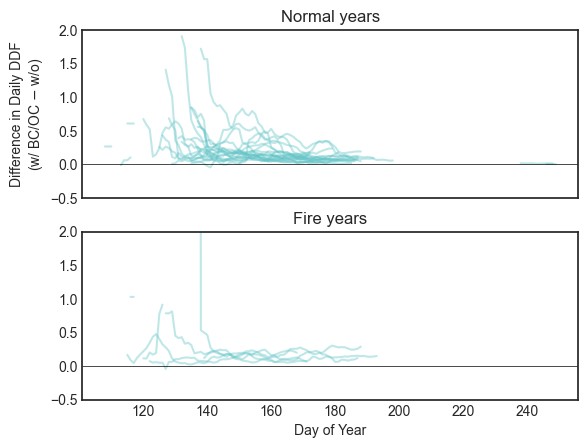

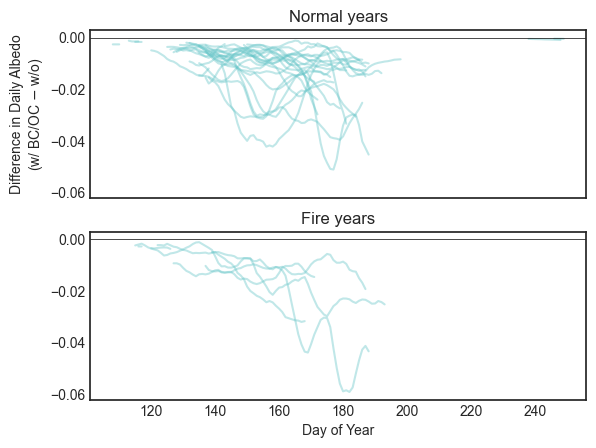

In [87]:
for plot_type in ['difference']:  # or 'values'
    fig_ddf, axes_ddf = plt.subplots(2, sharex=True, sharey=True)
    fig_albedo, axes_albedo = plt.subplots(2, sharex=True, sharey=True)

    for s, site in enumerate(['AU']):   # ,'B','D','Z'
        cc = colors[s]

        ds_base = xr.open_dataset(base_fp + f'gulkana{site}_2026_02_03_base_long_0.nc')
        ds_noBCOC = xr.open_dataset(base_fp + f'gulkana{site}_2026_02_03_noBCOC_long_0.nc')
        ds_dict = {'wBCOC': ds_base, 'base': ds_noBCOC}

        for axd, axa, years, label in zip(
            axes_ddf, axes_albedo,
            [base_years, fire_years],
            ['Normal years', 'Fire years']
        ):

            for year in years:
                if year < 2000 or pd.to_datetime(f'{year}-05-01') not in ds_base.time:
                    continue

                # --- extract per-year subset ---
                year_slice = slice(f"{year}-04-01", f"{year}-10-01")

                # compute per-dataset DDF + albedo for this year
                per_dataset = {}

                for dataset in ['base', 'wBCOC']:
                    ds = ds_dict[dataset]
                    subset = ds.sel(time=year_slice)

                    melt = subset['melt'].resample(time='1D').sum() * 1000
                    PDDs = subset['airtemp'].resample(time='1D').mean().clip(min=0)
                    albedo_daily = subset['albedo'].resample(time='1D').mean()

                    snowdepth = (
                        subset.where(subset['layertype'] < 2)['layerheight']
                        .sum(dim='layer')
                        .resample(time='1D')
                        .min()
                    )
                    
                    layertype_min = (
                        subset['layertype'].isel(layer=0)
                        .resample(time='1D')
                        .min()
                        .astype(int)
                    )

                    # --- snow ---
                    cond_snow = (melt > 2) & (snowdepth > 0.05) & (PDDs > 0)
                    ddf_snow = melt.where(cond_snow) / PDDs.where(cond_snow)

                    # --- ice ---
                    cond_ice = layertype_min > 1
                    ddf_ice = melt.where(cond_ice) / PDDs

                    per_dataset[dataset] = {
                        "snow": ddf_snow,
                        "ice": ddf_ice,
                        "albedo": albedo_daily.where(cond_snow),
                    }

                # ---------------------------------------------------------
                # compute differences PER YEAR (wBCOC − base)
                # ---------------------------------------------------------
                snow_diff = (per_dataset['wBCOC']['snow'] -
                             per_dataset['base']['snow']).rolling(time=7, center=True, min_periods=5).mean()

                ice_diff = (per_dataset['wBCOC']['ice'] -
                            per_dataset['base']['ice']).rolling(time=7, center=True, min_periods=5).mean()

                albedo_diff = (per_dataset['wBCOC']['albedo'] -
                               per_dataset['base']['albedo']).rolling(time=7, center=True, min_periods=5).mean()

                # x-axis = DOY
                doy = snow_diff['time'].dt.dayofyear

                # ---------------------------------------------------------
                # Plot each year as its own line
                # ---------------------------------------------------------
                if plot_type == 'difference':
                    axd.plot(doy, snow_diff, color=cc, alpha=0.4, label=str(year))
                    axa.plot(doy, albedo_diff, color=cc, alpha=0.4, label=str(year))
                    # axd.text(doy[~np.isnan(snow_diff)][0], snow_diff[~np.isnan(snow_diff)][0],str(year))

            axd.axhline(0, color='k', linewidth=0.5)
            axa.axhline(0, color='k', linewidth=0.5)
            axd.set_title(label)
            axa.set_title(label)

    axd.set_xlabel("Day of Year")
    axa.set_xlabel("Day of Year")

    ylabel = 'Difference in Daily DDF\n(w/ BC/OC $-$ w/o)'
    axes_ddf[0].set_ylabel(ylabel)
    axd.set_ylim(-0.5,2)

    ylabel = 'Difference in Daily Albedo\n(w/ BC/OC $-$ w/o)'
    axes_albedo[0].set_ylabel(ylabel)

    plt.show()

Normal years 0.1706265264000621
Fire years 0.2513602818584726


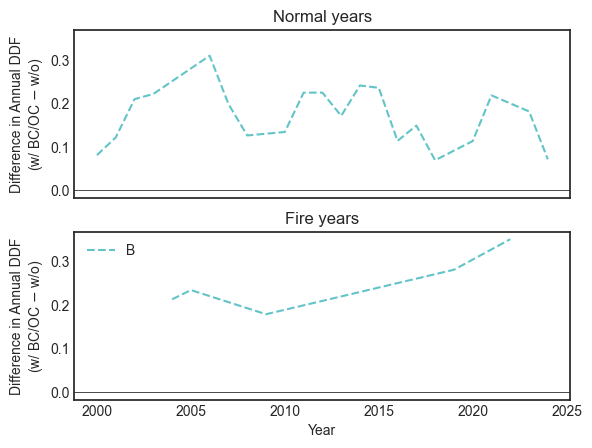

In [36]:
plot_type = 'difference'
fig, axes = plt.subplots(2, sharex=True, sharey=True)
for s, site in enumerate(['B']):
    ds_base = xr.open_dataset(base_fp + f'gulkana{site}_2026_02_03_base_long_0.nc')
    ds_noBCOC = xr.open_dataset(base_fp + f'gulkana{site}_2026_02_03_noBCOC_long_0.nc')
    # ds_noBCOC = ds_base
    ds_dict = {'wBCOC':ds_base, 'base':ds_noBCOC}
    linestyles = ['-','--']
    
    for ax, years, label in zip(axes,
                                [base_years, fire_years],
                                ['Normal years', 'Fire years']):

        x_ice = []
        y_ice = []
        x_snow = []
        y_snow = []
        for ls, dataset in zip(['-','--'], ['base','wBCOC']):
            ds = ds_dict[dataset]
            # collect daily ddf values across selected years
            ddfs_snow = []
            ddfs_ice = []

            for year in years:
                if year < 2000 or year > 2024:
                    ddfs_snow.append(np.nan)
                    ddfs_ice.append(np.nan)
                    continue
                
                # slice to Apr 1 – Oct 1 for that year
                subset = ds.sel(time=slice(f"{year}-04-01", f"{year}-10-01"))
                melt = subset['melt'].resample(time='1D').sum() * 1000
                PDDs = subset['airtemp'].resample(time='1D').mean().clip(min=0)
                albedo = subset['albedo'].resample(time='1D').mean()
                layertype = subset['layertype'].isel(layer=0).resample(time='1D').median()

                condition = layertype < 1
                seasonal_ddf = melt.where(condition).sum() / PDDs.where(condition).sum()
                ddfs_snow.append(seasonal_ddf.values)

                condition = layertype >= 1
                seasonal_ddf = melt.where(condition).sum() / PDDs.where(condition).sum()
                ddfs_ice.append(seasonal_ddf.values)

            # plot one line per category
            if plot_type == 'values':
                ax.plot(years, seasonal_ddf,
                        color=colors[s], linestyle=ls)
                ax.plot(years, seasonal_ddf,
                        color=colors[s], linestyle=ls)
            elif plot_type == 'difference':
                y_snow.append(np.array(ddfs_snow))
                y_ice.append(np.array(ddfs_ice))
            # if ls == '-':
            #     ax.plot(np.nan, np.nan, color=colors[s], label=f'Snow')
            #     ax.plot(np.nan, np.nan, color=colors[s], label=f'Ice')
        if plot_type == 'difference':
            # ax.plot(years, y_ice[1] - y_ice[0],
            #             color=colors[1], linestyle=ls)
            ax.plot(years, y_snow[1] - y_snow[0],
                    color=colors[s], linestyle=ls, label=site)
            print(label, np.nanmean(y_snow[1] - y_snow[0]))
            ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(label)

ax.set_xlabel('Year')
ylabel = 'Annual DDF' if plot_type != 'difference' else 'Difference in Annual DDF\n(w/ BC/OC $-$ w/o)'
ax.set_ylabel(ylabel)
axes[0].set_ylabel(ylabel)
if plot_type != 'difference':
    ax.plot(np.nan, np.nan, color='gray', linestyle='-', label='With BC/OC')
    ax.plot(np.nan, np.nan, color='gray', linestyle='--', label='No BC/OC')
ax.legend()
plt.show()